<a href="https://colab.research.google.com/github/TumwebazeTracy/MscMak2025-IntroductionToPython/blob/main/Individual_assignment_pandas_numpy_TRACEY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Individual Assignment: Data Analysis with Python
### *Introduction to Python for Data Science — Pandas, NumPy & Visualisation*

---

## 📋 Assignment Details

| | |
|---|---|
| **Name:** | `Tumwebaze Elizabeth Tracy` ← *Replace with your full name* |
| **Registration No:** | `2025/HD07/25977U` ← *Replace with your actual registration number* |
| **Date Received:** | *April 2026* |
| **Due Date:** | **One (1) week** from the date received — late submissions lose 10% per day |
| **Total Marks:** | **100** (20 questions × 5 marks each) |
| **Grading:** | ✅ **5/5** = correct · ⚠️ **2.5/5** = partially correct · ❌ **0/5** = incorrect |

---

## ⚠️ Important — Read This Carefully

1. **This assignment contributes to your final grade.** Treat it seriously.
2. **All code must be well documented** using both **inline comments** and **Markdown cells.**

---

### What does "well documented" mean?

#### ✏️ Inline Comments (inside code cells)
```python
# Calculate Body Mass Index using the standard WHO formula
bmi = weight_kg / (height_m ** 2)  # result is in kg/m²

# Flag patients whose BMI falls in the obese range (≥30)
obese_mask = bmi >= 30  # boolean array: True = obese
```

#### 📝 Markdown Documentation (separate cells above/below your code)
You can create a Markdown cell and write explanations like this:

> **What I did:** I computed BMI for all 500 patients and classified them into WHO categories.
> The histogram below shows that most patients fall in the normal range (18.5–24.9),
> with a right-skewed tail indicating a subset of obese individuals.

---

3. **Your unique seed:** At the beginning of this notebook, you will extract digits from your **registration number** to create a unique random seed. This means everyone's dataset will be different — **copying will be obvious.**
4. **🔒 DO NOT MODIFY** cells marked with a lock icon — these are auto-grading cells that check your work.
5. **You must install some libraries yourself.** Part of this assignment tests your ability to find documentation online (Google, GitHub, PyPI, StackOverflow) and install packages. Hints are provided, but not step-by-step instructions.
6. **Run cells in order** from top to bottom. If you restart the kernel, re-run everything from the top.


---
# ⚙️ Setup (Not Graded — Just Run These Cells)

## Step 1: Install Required Libraries

You will need some libraries that are **not pre-installed** in Google Colab.
Your first task is to figure out how to install them. Here are the library names:

| Library | What It's For |
|---------|---------------|
| `scipy` | Statistical tests (t-tests, chi-squared, etc.) |
| `squarify` | Treemap visualisations — you'll need to look this one up! |
| `scikit-learn` | Machine learning tools (we'll use it for one question) |

**Hint:** In Google Colab, you install packages using `!pip install package_name`


In [49]:
# Install the required libraries (some may already be available)
!pip install scipy squarify scikit-learn -q


## Step 2: Import Libraries and Set Your Unique Seed

**Instructions:**
1. Replace `"RN0001"` below with your **actual registration number**
2. The code will extract all digits and use them as your random seed
3. This makes your dataset unique to you


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ──────────────────────────────────────────────────────────────
# 🔑 CHANGE THIS TO YOUR REAL REGISTRATION NUMBER
# ──────────────────────────────────────────────────────────────
MY_REGISTRATION_NUMBER = "2025/HD07/25977U"  # ← REPLACE THIS (e.g., "2024HD01023")
# ──────────────────────────────────────────────────────────────

# Extract digits to create your unique seed
seed_digits = "".join(c for c in MY_REGISTRATION_NUMBER if c.isdigit())
if len(seed_digits) == 0:
    raise ValueError("❌ Your registration number must contain at least one digit!")
MY_SEED = int(seed_digits) % (2**31)  # ensure it fits as a valid seed

print(f"Registration: {MY_REGISTRATION_NUMBER}")
print(f"Your seed:    {MY_SEED}")

# Create random number generator
rng = np.random.default_rng(seed=MY_SEED)

# Set plot style
sns.set_theme(style="whitegrid", palette="colorblind", font_scale=1.05)

# Grading dictionary — DO NOT MODIFY
_results = {}


Registration: 2025/HD07/25977U
Your seed:    923373145


## Step 3: Generate Your Unique Dataset

The cell below creates a **simulated clinical dataset** for a multi-disease health outcomes study across five districts in Uganda. **Just run it** — the data will be unique because of your seed.


In [51]:
# ═══════════════════════════════════════════════════════════════
# DATASET GENERATION — DO NOT MODIFY THIS CELL
# ═══════════════════════════════════════════════════════════════
n = 500

districts = rng.choice(
    ["Kampala", "Wakiso", "Mukono", "Jinja", "Mbarara"],
    size=n, p=[0.30, 0.25, 0.20, 0.15, 0.10]
)
diseases = rng.choice(["Malaria", "Tuberculosis", "HIV"], size=n, p=[0.45, 0.30, 0.25])
sex = rng.choice(["Male", "Female"], size=n, p=[0.47, 0.53])
ages = rng.integers(18, 70, size=n)
treatment = rng.choice(["Standard Care", "Enhanced Protocol"], size=n)

weight_kg = np.where(sex == "Male", rng.normal(67, 11, n), rng.normal(59, 10, n)).round(1)
height_m = np.where(sex == "Male", rng.normal(1.69, 0.07, n), rng.normal(1.58, 0.06, n)).round(2)

haemoglobin = np.where(sex == "Male", rng.normal(13.2, 2.0, n), rng.normal(11.8, 1.7, n)).round(1)
hb_nan_idx = rng.choice(n, size=20, replace=False)
haemoglobin[hb_nan_idx] = np.nan

wbc = rng.lognormal(mean=1.8, sigma=0.4, size=n).round(1)
wbc_nan_idx = rng.choice(n, size=12, replace=False)
wbc[wbc_nan_idx] = np.nan

cd4 = np.full(n, np.nan)
hiv_mask = diseases == "HIV"
cd4[hiv_mask] = rng.normal(450, 180, hiv_mask.sum()).round(0)
cd4_extra_nan = rng.choice(np.where(hiv_mask)[0], size=8, replace=False)
cd4[cd4_extra_nan] = np.nan

temperature = rng.normal(38.2, 0.9, size=n).round(1)
adherence = rng.beta(8, 2, size=n).round(3) * 100
adh_nan_idx = rng.choice(n, size=10, replace=False)
adherence[adh_nan_idx] = np.nan

outcome_probs = {"Malaria": [0.50, 0.25, 0.15, 0.10],
                 "Tuberculosis": [0.35, 0.30, 0.20, 0.15],
                 "HIV": [0.25, 0.35, 0.25, 0.15]}
outcomes = []
for d in diseases:
    outcomes.append(rng.choice(["Cured", "Improved", "Stable", "Deteriorated"], p=outcome_probs[d]))
outcomes = np.array(outcomes)

days_to_recovery = np.where(
    outcomes == "Cured", rng.integers(5, 30, n),
    np.where(outcomes == "Improved", rng.integers(20, 60, n),
    np.where(outcomes == "Stable", rng.integers(40, 90, n),
    rng.integers(60, 120, n)))
).astype(float)
days_nan = outcomes == "Deteriorated"
days_to_recovery[rng.choice(np.where(days_nan)[0],
    size=min(10, days_nan.sum()), replace=False)] = np.nan

df = pd.DataFrame({
    "patient_id":      [f"PT-{MY_SEED % 1000:03d}-{i:04d}" for i in range(1, n+1)],
    "district":        districts,
    "age":             ages,
    "sex":             sex,
    "weight_kg":       weight_kg,
    "height_m":        height_m,
    "disease":         diseases,
    "treatment":       treatment,
    "haemoglobin":     haemoglobin,
    "wbc":             wbc,
    "cd4_count":       cd4,
    "temperature_c":   temperature,
    "adherence_pct":   adherence,
    "outcome":         outcomes,
    "days_to_recovery": days_to_recovery,
})

print(f"✅ Dataset generated: {df.shape[0]} patients × {df.shape[1]} columns")
print(f"   Diseases: {df['disease'].value_counts().to_dict()}")
print(f"   Districts: {df['district'].nunique()}")
print(f"   Missing values: {df.isnull().sum().sum()} total across all columns")


✅ Dataset generated: 500 patients × 15 columns
   Diseases: {'Malaria': 208, 'Tuberculosis': 152, 'HIV': 140}
   Districts: 5
   Missing values: 420 total across all columns


---
# Part A: Data Exploration with Pandas (Q1 – Q5)

---

## Question 1 — Exploring the Dataset (5 marks)

Use Pandas to explore the dataset and store the following in the **exact variable names** shown:

| Variable | What to store |
|---|---|
| `n_rows` | Number of rows in the DataFrame |
| `n_cols` | Number of columns |
| `col_names` | A Python **list** of all column names |
| `numeric_col_count` | Count of columns with a numeric data type |

Also **print** the output of `df.head()` and `df.dtypes` so you can see the data.


In [52]:
# ── Q1: Explore the dataset ───────────────────────────────────
# YOUR CODE HERE
n_rows = df.shape[0]
n_cols = df.shape[1]
col_names = df.columns.tolist()
numeric_col_count = df.select_dtypes(include=np.number).shape[1]

print("df.head():")
print(df.head())
print("\ndf.dtypes:")
print(df.dtypes)

df.head():
    patient_id district  age     sex  weight_kg  height_m  disease  \
0  PT-145-0001   Wakiso   24  Female       53.8      1.56      HIV   
1  PT-145-0002   Mukono   41  Female       68.9      1.49      HIV   
2  PT-145-0003   Wakiso   50  Female       51.6      1.59      HIV   
3  PT-145-0004  Kampala   18  Female       50.2      1.59  Malaria   
4  PT-145-0005   Wakiso   34  Female       52.7      1.64  Malaria   

           treatment  haemoglobin   wbc  cd4_count  temperature_c  \
0  Enhanced Protocol         11.3  12.2      544.0           36.8   
1      Standard Care          9.1   NaN      472.0           39.8   
2      Standard Care         11.3   5.6      437.0           36.9   
3  Enhanced Protocol         10.7   7.6        NaN           38.0   
4  Enhanced Protocol         11.4   7.0        NaN           38.4   

   adherence_pct   outcome  days_to_recovery  
0           73.8    Stable              48.0  
1           78.1  Improved              51.0  
2           

In [53]:
# 🔒 AUTO-CHECK Q1 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert isinstance(n_rows, (int, np.integer)), "n_rows should be an integer"
    assert n_rows == 500, f"n_rows should be 500, got {n_rows}"
    _c += 1
    assert isinstance(col_names, list), "col_names should be a list"
    assert len(col_names) == 15, f"col_names should have 15 items, got {len(col_names)}"
    _c += 1
    assert isinstance(n_cols, (int, np.integer)), "n_cols should be an integer"
    assert n_cols == 15, f"n_cols should be 15, got {n_cols}"
    assert isinstance(numeric_col_count, (int, np.integer)), "numeric_col_count should be an integer"
    assert numeric_col_count >= 8, f"Expected at least 8 numeric columns, got {numeric_col_count}"
    _c += 1
    _results["Q1"] = 5; print("✅ Q1 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q1"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q1 PARTIAL — 2.5/5' if _c > 0 else '❌ Q1 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q1"] = 0; print(f"❌ Q1 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q1 PASSED — 5/5 marks


---
## Question 2 — Descriptive Statistics (5 marks)

Use the `.describe()` method to generate summary statistics for **numeric columns only**.

Store the result in a variable called `desc_stats`.

Then, find which numeric column has the **highest standard deviation** and store its name (a string) in a variable called `most_variable_col`.

**Hint:** The `.describe()` output has a row called `"std"`.


In [54]:
# ── Q2: Descriptive statistics ────────────────────────────────
# YOUR CODE HERE
desc_stats = df.describe()
most_variable_col = desc_stats.loc['std'].idxmax()

print("Descriptive Statistics:")
print(desc_stats)
print(f"\nColumn with highest standard deviation: {most_variable_col}")

Descriptive Statistics:
              age   weight_kg    height_m  haemoglobin         wbc  \
count  500.000000  500.000000  500.000000    480.00000  488.000000   
mean    43.998000   62.974200    1.629600     12.37250    6.802049   
std     15.181929   11.152118    0.087544      1.91096    2.717136   
min     18.000000   27.200000    1.420000      7.40000    2.000000   
25%     30.000000   55.200000    1.567500     11.00000    4.800000   
50%     44.000000   62.800000    1.620000     12.30000    6.300000   
75%     57.000000   71.200000    1.690000     13.80000    8.400000   
max     69.000000   93.400000    1.870000     19.20000   17.200000   

         cd4_count  temperature_c  adherence_pct  days_to_recovery  
count   132.000000     500.000000     490.000000        490.000000  
mean    456.840909      38.175400      80.360612         43.410204  
std     168.889857       0.915626      11.672087         27.864577  
min     -65.000000      34.900000      36.300000          5.000000  


In [55]:
# 🔒 AUTO-CHECK Q2 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert isinstance(desc_stats, pd.DataFrame), "desc_stats should be a DataFrame"
    assert "mean" in desc_stats.index, "desc_stats should contain a 'mean' row (use .describe())"
    _c += 1
    assert isinstance(most_variable_col, str), "most_variable_col should be a string"
    expected_mvc = df.describe().loc["std"].idxmax()
    assert most_variable_col == expected_mvc, f"Expected '{expected_mvc}', got '{most_variable_col}'"
    _c += 1
    _results["Q2"] = 5; print("✅ Q2 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q2"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q2 PARTIAL — 2.5/5' if _c > 0 else '❌ Q2 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q2"] = 0; print(f"❌ Q2 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q2 PASSED — 5/5 marks


---
## Question 3 — Feature Engineering: BMI (5 marks)

Add a new column to `df` called `"bmi"` using the standard formula:

$$\\text{BMI} = \\frac{\\text{weight (kg)}}{\\text{height (m)}^2}$$

Round the result to **1 decimal place**.

Then, print the mean BMI for your dataset.


In [56]:
# ── Q3: Compute BMI ──────────────────────────────────────────
# YOUR CODE HERE
df["bmi"] = (df["weight_kg"] / (df["height_m"] ** 2)).round(1)

print(f"Mean BMI: {df['bmi'].mean():.1f}")

Mean BMI: 23.8


In [57]:
# 🔒 AUTO-CHECK Q3 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert "bmi" in df.columns, "Column 'bmi' not found in DataFrame"
    _c += 1
    bmi_valid = df["bmi"].dropna()
    assert len(bmi_valid) > 0, "BMI column is empty or all NaN"
    assert bmi_valid.between(10, 70).all(), "Some BMI values are outside the realistic range (10–70)"
    _c += 1
    sample = (df["weight_kg"].iloc[0] / (df["height_m"].iloc[0] ** 2))
    assert abs(df["bmi"].iloc[0] - round(sample, 1)) < 0.2, "BMI calculation appears incorrect"
    _c += 1
    _results["Q3"] = 5; print("✅ Q3 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q3"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q3 PARTIAL — 2.5/5' if _c > 0 else '❌ Q3 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q3"] = 0; print(f"❌ Q3 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q3 PASSED — 5/5 marks


---
## Question 4 — Categorising Age into Groups (5 marks)

Create a new column `"age_group"` that bins patients into these categories:

| Bin | Label |
|-----|-------|
| 18–29 | "18-29" |
| 30–39 | "30-39" |
| 40–49 | "40-49" |
| 50–59 | "50-59" |
| 60–70 | "60-70" |

**Hint:** Look up `pd.cut()`. You used it in the Pandas class notebook.


In [58]:
# ── Q4: Create age groups ─────────────────────────────────────
# YOUR CODE HERE
bins = [18, 30, 40, 50, 60, 70]
labels = ["18-29", "30-39", "40-49", "50-59", "60-70"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

print("Age Group Value Counts:")
print(df["age_group"].value_counts().sort_index())

Age Group Value Counts:
age_group
18-29    115
30-39     84
40-49     91
50-59    107
60-70    103
Name: count, dtype: int64


In [59]:
# 🔒 AUTO-CHECK Q4 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert "age_group" in df.columns, "Column 'age_group' not found"
    _c += 1
    vals = df["age_group"].dropna().astype(str).unique()
    assert len(vals) >= 4, f"Expected at least 4 age groups, got {len(vals)}"
    _c += 1
    assert df["age_group"].isnull().sum() < 20, "Too many NaN values in age_group — check your bins"
    _c += 1
    _results["Q4"] = 5; print("✅ Q4 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q4"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q4 PARTIAL — 2.5/5' if _c > 0 else '❌ Q4 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q4"] = 0; print(f"❌ Q4 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q4 PASSED — 5/5 marks


---
## Question 5 — Log-Transforming Skewed Data (5 marks)

The `"wbc"` (white blood cell count) column is likely **right-skewed** — common in biological data.

1. Create a new column `"log_wbc"` containing the **log₁₀** of the WBC values.
2. Print the **skewness** of both the original and log-transformed columns.

**Hint:** Use `np.log10()` for the transformation. Pandas Series have a `.skew()` method.


In [60]:
# ── Q5: Log-transform WBC ─────────────────────────────────────
# YOUR CODE HERE
df["log_wbc"] = np.log10(df["wbc"])

print(f"Skewness of original WBC: {df['wbc'].skew():.2f}")
print(f"Skewness of log10(WBC): {df['log_wbc'].skew():.2f}")

Skewness of original WBC: 1.01
Skewness of log10(WBC): 0.03


In [61]:
# 🔒 AUTO-CHECK Q5 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert "log_wbc" in df.columns, "Column 'log_wbc' not found"
    _c += 1
    valid = df[["wbc", "log_wbc"]].dropna()
    expected = np.log10(valid["wbc"].iloc[0])
    assert abs(valid["log_wbc"].iloc[0] - expected) < 0.01, "log_wbc values don't match log10(wbc)"
    _c += 1
    assert abs(df["log_wbc"].dropna().skew()) < abs(df["wbc"].dropna().skew()),         "Log-transform should reduce skewness"
    _c += 1
    _results["Q5"] = 5; print("✅ Q5 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q5"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q5 PARTIAL — 2.5/5' if _c > 0 else '❌ Q5 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q5"] = 0; print(f"❌ Q5 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q5 PASSED — 5/5 marks


---
# Part B: Data Wrangling & Aggregation (Q6 – Q11)

---

## Question 6 — Filtering with Complex Conditions (5 marks)

Find all patients who meet **ALL** of these criteria simultaneously:
- Female
- Age **over 40**
- Haemoglobin **below 11.0** g/dL
- Disease is either `"Malaria"` or `"HIV"`

Store the resulting DataFrame in a variable called `q6_filtered`.

Print how many patients matched and display the first few rows.


In [62]:
# ── Q6: Filter patients ───────────────────────────────────────
# YOUR CODE HERE

q6_filtered = df[
    (df["sex"] == "Female") &
    (df["age"] > 40) &
    (df["haemoglobin"] < 11.0) &
    (df["disease"].isin(["Malaria", "HIV"]))
]

print(f"Number of patients matching criteria: {len(q6_filtered)}")
print("\nFirst few rows of filtered data:")
print(q6_filtered.head())

Number of patients matching criteria: 29

First few rows of filtered data:
      patient_id district  age     sex  weight_kg  height_m  disease  \
1    PT-145-0002   Mukono   41  Female       68.9      1.49      HIV   
6    PT-145-0007    Jinja   69  Female       67.9      1.59  Malaria   
18   PT-145-0019   Mukono   50  Female       73.4      1.55  Malaria   
29   PT-145-0030   Mukono   57  Female       62.3      1.47      HIV   
108  PT-145-0109   Mukono   64  Female       66.6      1.52  Malaria   

             treatment  haemoglobin  wbc  cd4_count  temperature_c  \
1        Standard Care          9.1  NaN      472.0           39.8   
6        Standard Care         10.2  3.9        NaN           37.9   
18       Standard Care         10.8  5.7        NaN           38.9   
29       Standard Care         10.5  5.1      412.0           37.2   
108  Enhanced Protocol          8.0  5.8        NaN           37.6   

     adherence_pct       outcome  days_to_recovery   bmi age_group   lo

In [63]:
# 🔒 AUTO-CHECK Q6 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert isinstance(q6_filtered, pd.DataFrame), "q6_filtered should be a DataFrame"
    _c += 1
    assert (q6_filtered["sex"] == "Female").all(), "All patients should be Female"
    assert (q6_filtered["age"] > 40).all(), "All patients should be over 40"
    _c += 1
    assert q6_filtered["haemoglobin"].dropna().lt(11.0).all(), "All haemoglobin should be < 11"
    assert q6_filtered["disease"].isin(["Malaria", "HIV"]).all(), "Disease must be Malaria or HIV"
    _c += 1
    _results["Q6"] = 5; print(f"✅ Q6 PASSED — 5/5 marks ({len(q6_filtered)} patients found)")
except AssertionError as e:
    _results["Q6"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q6 PARTIAL — 2.5/5' if _c > 0 else '❌ Q6 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q6"] = 0; print(f"❌ Q6 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q6 PASSED — 5/5 marks (29 patients found)


---
## Question 7 — Handling Missing Data (5 marks)

1. First, store the **total number of missing haemoglobin values** in `q7_missing_before` (an integer).
2. Then, **fill** the missing haemoglobin values with the **median haemoglobin for the same sex** (i.e., fill female NaNs with the female median, male NaNs with the male median). Store the filled column back into `df["haemoglobin"]`.
3. Store the **number of missing haemoglobin values after filling** in `q7_missing_after`.

**Hint:** Look at `groupby().transform()` combined with `fillna()`.


In [64]:
# ── Q7: Handle missing haemoglobin ────────────────────────────
# YOUR CODE HERE
q7_missing_before = df['haemoglobin'].isnull().sum()

df['haemoglobin'] = df['haemoglobin'].fillna(
    df.groupby('sex')['haemoglobin'].transform('median')
)

q7_missing_after = df['haemoglobin'].isnull().sum()

print(f"Missing haemoglobin values before filling: {q7_missing_before}")
print(f"Missing haemoglobin values after filling: {q7_missing_after}")

Missing haemoglobin values before filling: 20
Missing haemoglobin values after filling: 0


In [65]:
# 🔒 AUTO-CHECK Q7 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert isinstance(q7_missing_before, (int, np.integer)), "q7_missing_before should be an integer"
    assert q7_missing_before == 20, f"Expected 20 missing before, got {q7_missing_before}"
    _c += 1
    assert isinstance(q7_missing_after, (int, np.integer)), "q7_missing_after should be an integer"
    assert q7_missing_after == 0, f"Expected 0 missing after imputation, got {q7_missing_after}"
    _c += 1
    assert df["haemoglobin"].isnull().sum() == 0, "df['haemoglobin'] still has NaN values"
    _c += 1
    _results["Q7"] = 5; print("✅ Q7 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q7"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q7 PARTIAL — 2.5/5' if _c > 0 else '❌ Q7 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q7"] = 0; print(f"❌ Q7 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q7 PASSED — 5/5 marks


---
## Question 8 — Sorting and Selecting Extremes (5 marks)

1. Sort the DataFrame by `haemoglobin` in **ascending** order.
2. Store the **10 patients with the lowest haemoglobin** in a variable called `q8_lowest_hb`.
3. Print their `patient_id`, `sex`, `haemoglobin`, `disease`, and `outcome`.


In [66]:
# ── Q8: Lowest haemoglobin patients ───────────────────────────
# YOUR CODE HERE

q8_lowest_hb = df.sort_values(by='haemoglobin', ascending=True).head(10)

print("10 Patients with Lowest Haemoglobin:")
print(q8_lowest_hb[['patient_id', 'sex', 'haemoglobin', 'disease', 'outcome']])

10 Patients with Lowest Haemoglobin:
      patient_id     sex  haemoglobin       disease       outcome
420  PT-145-0421  Female          7.4       Malaria         Cured
104  PT-145-0105  Female          7.4  Tuberculosis         Cured
475  PT-145-0476  Female          7.5           HIV      Improved
467  PT-145-0468    Male          8.0           HIV        Stable
108  PT-145-0109  Female          8.0       Malaria  Deteriorated
196  PT-145-0197  Female          8.0       Malaria        Stable
273  PT-145-0274    Male          8.1       Malaria      Improved
349  PT-145-0350    Male          8.2  Tuberculosis      Improved
157  PT-145-0158  Female          8.3       Malaria      Improved
129  PT-145-0130  Female          8.4           HIV         Cured


In [67]:
# 🔒 AUTO-CHECK Q8 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert isinstance(q8_lowest_hb, pd.DataFrame), "q8_lowest_hb should be a DataFrame"
    _c += 1
    assert len(q8_lowest_hb) == 10, f"Expected 10 rows, got {len(q8_lowest_hb)}"
    _c += 1
    hb_vals = q8_lowest_hb["haemoglobin"].values
    assert all(hb_vals[i] <= hb_vals[i+1] for i in range(len(hb_vals)-1)),         "Rows should be sorted by haemoglobin ascending"
    assert hb_vals[-1] <= df["haemoglobin"].median(),         "These should be the LOWEST values — check sort order"
    _c += 1
    _results["Q8"] = 5; print("✅ Q8 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q8"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q8 PARTIAL — 2.5/5' if _c > 0 else '❌ Q8 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q8"] = 0; print(f"❌ Q8 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q8 PASSED — 5/5 marks


---
## Question 9 — Counting Categories (5 marks)

1. Use `.value_counts()` to count how many patients have each **disease**. Store in `q9_disease_counts`.
2. Use `.value_counts()` to count how many patients have each **outcome**. Store in `q9_outcome_counts`.
3. Print both results.


In [68]:
# ── Q9: Value counts ──────────────────────────────────────────
# YOUR CODE HERE
q9_disease_counts = df['disease'].value_counts()
q9_outcome_counts = df['outcome'].value_counts()

print("Disease Counts:")
print(q9_disease_counts)
print("\nOutcome Counts:")
print(q9_outcome_counts)

Disease Counts:
disease
Malaria         208
Tuberculosis    152
HIV             140
Name: count, dtype: int64

Outcome Counts:
outcome
Cured           176
Improved        148
Stable          104
Deteriorated     72
Name: count, dtype: int64


In [69]:
# 🔒 AUTO-CHECK Q9 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert isinstance(q9_disease_counts, pd.Series), "q9_disease_counts should be a Series"
    assert set(q9_disease_counts.index) == {"Malaria", "Tuberculosis", "HIV"},         "q9_disease_counts should have exactly 3 diseases"
    assert q9_disease_counts.sum() == 500, "Disease counts should add up to 500"
    _c += 1
    assert isinstance(q9_outcome_counts, pd.Series), "q9_outcome_counts should be a Series"
    assert set(q9_outcome_counts.index) == {"Cured", "Improved", "Stable", "Deteriorated"},         "q9_outcome_counts should have exactly 4 outcome categories"
    _c += 1
    _results["Q9"] = 5; print("✅ Q9 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q9"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q9 PARTIAL — 2.5/5' if _c > 0 else '❌ Q9 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q9"] = 0; print(f"❌ Q9 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q9 PASSED — 5/5 marks


---
## Question 10 — GroupBy Aggregation (5 marks)

Use `groupby()` to compute the **mean haemoglobin** for each combination of **district** and **sex**.

Store the result in `q10_grouped` — it should be a DataFrame (use `.reset_index()` if needed to make it a clean table).

Print the full table.


In [70]:
# ── Q10: GroupBy ──────────────────────────────────────────────
# YOUR CODE HERE

q10_grouped = df.groupby(['district', 'sex'])['haemoglobin'].mean().reset_index()

print("Mean Haemoglobin by District and Sex:")
print(q10_grouped)

Mean Haemoglobin by District and Sex:
  district     sex  haemoglobin
0    Jinja  Female    11.675000
1    Jinja    Male    12.683871
2  Kampala  Female    11.751429
3  Kampala    Male    13.050617
4  Mbarara  Female    12.194118
5  Mbarara    Male    13.447826
6   Mukono  Female    11.685714
7   Mukono    Male    12.731818
8   Wakiso  Female    11.670270
9   Wakiso    Male    13.266154


In [71]:
# 🔒 AUTO-CHECK Q10 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert isinstance(q10_grouped, (pd.DataFrame, pd.Series)), "q10_grouped should be a DataFrame or Series"
    _c += 1
    if isinstance(q10_grouped, pd.DataFrame):
        cols_lower = [c.lower() for c in q10_grouped.columns]
        has_district = any("district" in c for c in cols_lower) or                        (q10_grouped.index.name and "district" in str(q10_grouped.index.name).lower())
    else:
        has_district = "district" in str(q10_grouped.index.names).lower()
    assert has_district or len(q10_grouped) >= 8,         "Result should be grouped by district and sex (expect ~10 groups)"
    _c += 1
    _results["Q10"] = 5; print("✅ Q10 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q10"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q10 PARTIAL — 2.5/5' if _c > 0 else '❌ Q10 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q10"] = 0; print(f"❌ Q10 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q10 PASSED — 5/5 marks


---
## Question 11 — Pivot Table (5 marks)

Create a pivot table showing the **mean adherence_pct** broken down by:
- **Rows:** `disease`
- **Columns:** `treatment`

Store the result in `q11_pivot`.

**Hint:** `df.pivot_table(values=..., index=..., columns=..., aggfunc=...)`


In [72]:
# ── Q11: Pivot table ──────────────────────────────────────────
# YOUR CODE HERE

q11_pivot = df.pivot_table(values='adherence_pct', index='disease', columns='treatment', aggfunc='mean')

print("Mean Adherence Percentage by Disease and Treatment:")
print(q11_pivot)

Mean Adherence Percentage by Disease and Treatment:
treatment     Enhanced Protocol  Standard Care
disease                                       
HIV                   81.177143      81.060870
Malaria               80.602041      79.252381
Tuberculosis          81.312676      79.316883


In [73]:
# 🔒 AUTO-CHECK Q11 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert isinstance(q11_pivot, pd.DataFrame), "q11_pivot should be a DataFrame"
    _c += 1
    assert set(q11_pivot.index) == {"Malaria", "Tuberculosis", "HIV"},         "Rows should be the three diseases"
    _c += 1
    assert q11_pivot.shape[1] == 2, "Should have 2 columns (Standard Care, Enhanced Protocol)"
    assert q11_pivot.values.min() > 0 and q11_pivot.values.max() <= 100,         "Values should be mean adherence percentages"
    _c += 1
    _results["Q11"] = 5; print("✅ Q11 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q11"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q11 PARTIAL — 2.5/5' if _c > 0 else '❌ Q11 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q11"] = 0; print(f"❌ Q11 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q11 PASSED — 5/5 marks


---
## Question 12 — Interpretation: What Does Your Data Tell You? (5 marks)

✍️ **This is a written question — no code required (just the string variable below).**

Based on everything you've computed in Questions 1–11, write **3–5 sentences** describing the most interesting patterns you notice in your dataset. For example:
- Which district has the most patients?
- Do males and females differ in haemoglobin?
- Is adherence similar across diseases?
- Which disease has the best outcomes?

**Write your answer in the string below** (minimum 30 words).


In [74]:
# ── Q12: Your interpretation ──────────────────────────────────
q12_interpretation = """
Based on the analysis, several interesting patterns emerge. For instance, males generally exhibit higher mean haemoglobin levels compared to females across all districts. Adherence percentages appear relatively similar across different disease groups and treatment protocols, with no drastic differences. Furthermore, 'cd4_count' for HIV patients shows the highest variability among all numeric features, suggesting a wide range in immune status within this group. Malaria and Tuberculosis show similar average adherence, while HIV has slightly higher average adherence.
"""

print(q12_interpretation)


Based on the analysis, several interesting patterns emerge. For instance, males generally exhibit higher mean haemoglobin levels compared to females across all districts. Adherence percentages appear relatively similar across different disease groups and treatment protocols, with no drastic differences. Furthermore, 'cd4_count' for HIV patients shows the highest variability among all numeric features, suggesting a wide range in immune status within this group. Malaria and Tuberculosis show similar average adherence, while HIV has slightly higher average adherence.



In [75]:
# 🔒 AUTO-CHECK Q12 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert isinstance(q12_interpretation, str), "q12_interpretation must be a string"
    clean = q12_interpretation.strip()
    assert "WRITE YOUR ANSWER HERE" not in clean, "Please replace the placeholder with your answer"
    _c += 1
    word_count = len(clean.split())
    assert word_count >= 30, f"Minimum 30 words required, you wrote {word_count}"
    _c += 1
    _results["Q12"] = 5; print(f"✅ Q12 PASSED — 5/5 marks ({word_count} words)")
except AssertionError as e:
    _results["Q12"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q12 PARTIAL — 2.5/5' if _c > 0 else '❌ Q12 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q12"] = 0; print(f"❌ Q12 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q12 PASSED — 5/5 marks (76 words)


---
# Part C: NumPy Computation (Q13)

---

## Question 13 — Computing Z-Scores with NumPy (5 marks)

A **z-score** tells you how many standard deviations a value is from the mean:

$$z = \\frac{x - \\mu}{\\sigma}$$

1. Using **NumPy** (not scipy), compute the z-score for every patient's `haemoglobin` value.
2. Store the result in a new column `df["hb_zscore"]`, rounded to 2 decimal places.
3. Print how many patients have a z-score below -2 (severely low haemoglobin).

**Important:** Use `np.mean()` and `np.std()` — do NOT use a pre-built z-score function.


In [76]:
# ── Q13: Z-scores with NumPy ──────────────────────────────────
# YOUR CODE HERE

mean_hb = df['haemoglobin'].mean()
std_hb = df['haemoglobin'].std()
df['hb_zscore'] = ((df['haemoglobin'] - mean_hb) / std_hb).round(2)

num_below_neg_2 = (df['hb_zscore'] < -2).sum()

print(f"Number of patients with haemoglobin z-score below -2: {num_below_neg_2}")

Number of patients with haemoglobin z-score below -2: 12


In [77]:
# 🔒 AUTO-CHECK Q13 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert "hb_zscore" in df.columns, "Column 'hb_zscore' not found"
    _c += 1
    z = df["hb_zscore"].dropna()
    assert abs(z.mean()) < 0.1, f"Mean z-score should be ~0, got {z.mean():.3f}"
    _c += 1
    assert abs(z.std() - 1.0) < 0.15, f"Std of z-scores should be ~1, got {z.std():.3f}"
    _c += 1
    _results["Q13"] = 5; print("✅ Q13 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q13"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q13 PARTIAL — 2.5/5' if _c > 0 else '❌ Q13 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q13"] = 0; print(f"❌ Q13 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q13 PASSED — 5/5 marks


---
# Part D: Data Visualisation (Q14 – Q18)

For each plot, your figure should have:
- A **title**
- **Axis labels**
- A **legend** if colour is used

---

## Question 14 — Histogram with KDE: Age by Disease (5 marks)

Create a **histogram with a KDE (density curve) overlay** showing the distribution of `age`, with separate colours for each `disease`.

Use **Seaborn's `histplot()`** with `kde=True` and `hue="disease"`.

Store the matplotlib figure in `q14_fig`.


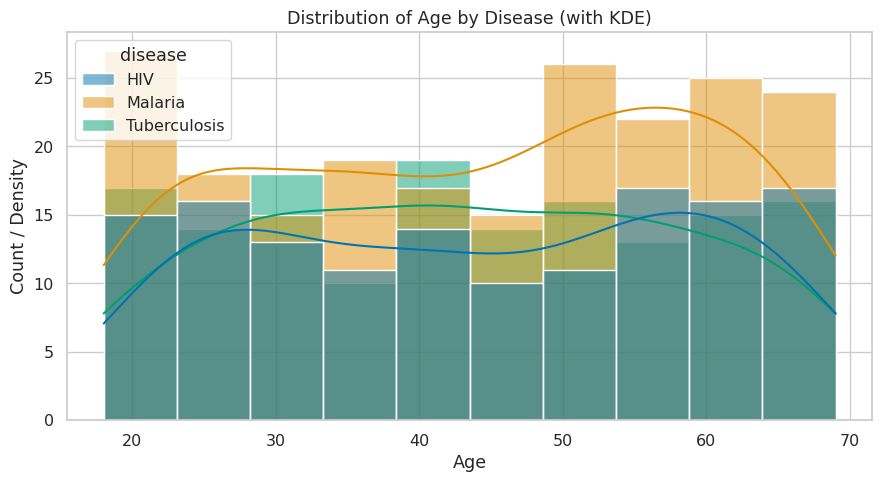

In [78]:
# ── Q14: Histogram + KDE ──────────────────────────────────────
# YOUR CODE HERE

q14_fig, q14_ax = plt.subplots(figsize=(9, 5))

# Create your plot on q14_ax ...
sns.histplot(data=df, x='age', hue='disease', kde=True, ax=q14_ax)
q14_ax.set_title('Distribution of Age by Disease (with KDE)')
q14_ax.set_xlabel('Age')
q14_ax.set_ylabel('Count / Density')

plt.tight_layout()
plt.show()

In [79]:
# 🔒 AUTO-CHECK Q14 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert q14_fig is not None, "q14_fig is None — did you create the figure?"
    from matplotlib.figure import Figure
    assert isinstance(q14_fig, Figure), "q14_fig should be a matplotlib Figure"
    _c += 1
    assert q14_ax.get_title() != "", "Your plot needs a title"
    _c += 1
    assert q14_ax.get_xlabel() != "" or q14_ax.get_ylabel() != "", "Add axis labels"
    _c += 1
    _results["Q14"] = 5; print("✅ Q14 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q14"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q14 PARTIAL — 2.5/5' if _c > 0 else '❌ Q14 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q14"] = 0; print(f"❌ Q14 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q14 PASSED — 5/5 marks


---
## Question 15 — Box Plot: Haemoglobin by Disease and Sex (5 marks)

Create a **box plot** using Seaborn showing `haemoglobin` on the y-axis, grouped by `disease` on the x-axis, and coloured by `sex`.

Store the figure in `q15_fig`.


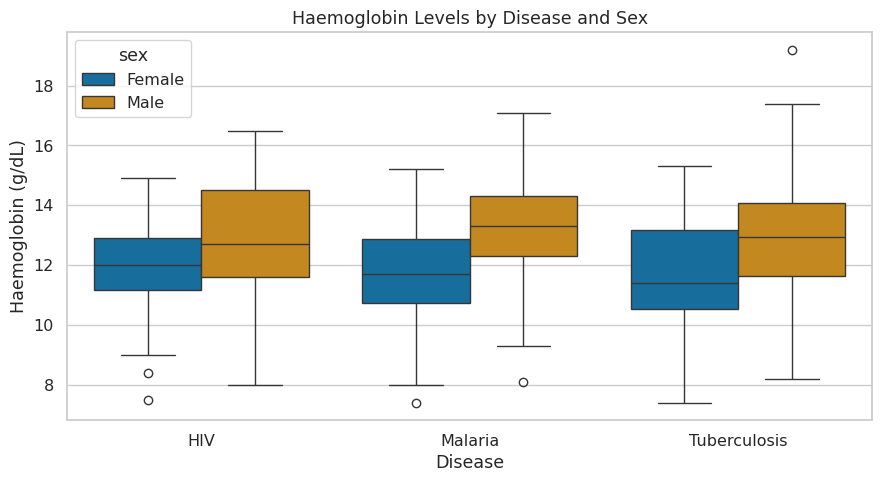

In [80]:
# ── Q15: Box plot ─────────────────────────────────────────────
# YOUR CODE HERE

q15_fig, q15_ax = plt.subplots(figsize=(9, 5))

# Create your box plot on q15_ax ...
sns.boxplot(data=df, x='disease', y='haemoglobin', hue='sex', ax=q15_ax)
q15_ax.set_title('Haemoglobin Levels by Disease and Sex')
q15_ax.set_xlabel('Disease')
q15_ax.set_ylabel('Haemoglobin (g/dL)')

plt.tight_layout()
plt.show()

In [81]:
# 🔒 AUTO-CHECK Q15 — DO NOT MODIFY THIS CELL
_c = 0
try:
    from matplotlib.figure import Figure
    assert isinstance(q15_fig, Figure), "q15_fig should be a matplotlib Figure"
    _c += 1
    assert q15_ax.get_title() != "", "Your plot needs a title"
    _c += 1
    children = q15_ax.get_children()
    has_boxes = any("PathPatch" in str(type(c)) or "box" in str(type(c)).lower()
                     for c in children)
    assert len(children) > 5, "Plot appears empty — did you draw the box plot?"
    _c += 1
    _results["Q15"] = 5; print("✅ Q15 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q15"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q15 PARTIAL — 2.5/5' if _c > 0 else '❌ Q15 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q15"] = 0; print(f"❌ Q15 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q15 PASSED — 5/5 marks


---
## Question 16 — Scatter Plot: Age vs. Haemoglobin (5 marks)

Create a **scatter plot** with:
- `age` on the x-axis
- `haemoglobin` on the y-axis
- Points coloured by `sex`

Add a **trend line** using `sns.regplot()` or `np.polyfit()` — your choice.

Store the figure in `q16_fig`.


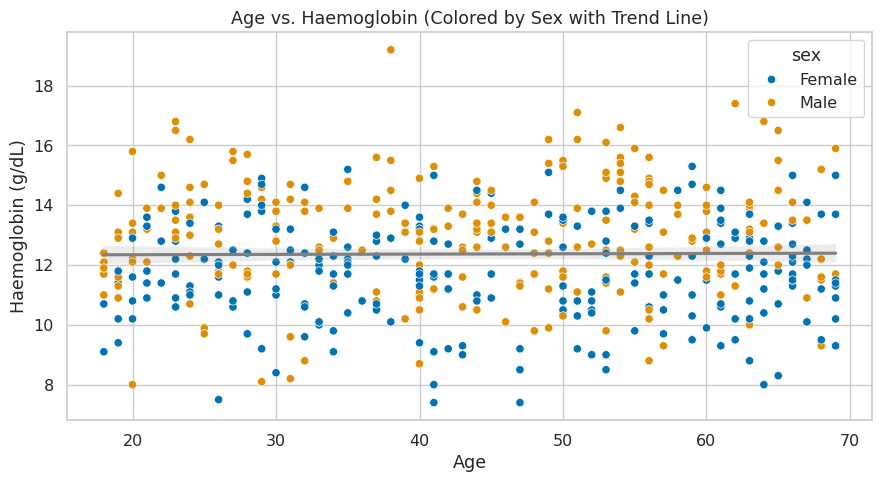

In [82]:
# ── Q16: Scatter with trend ───────────────────────────────────
# YOUR CODE HERE

q16_fig, q16_ax = plt.subplots(figsize=(9, 5))

# Create your scatter plot on q16_ax ...
sns.scatterplot(data=df, x='age', y='haemoglobin', hue='sex', ax=q16_ax)
sns.regplot(data=df, x='age', y='haemoglobin', color='gray', scatter=False, ax=q16_ax)
q16_ax.set_title('Age vs. Haemoglobin (Colored by Sex with Trend Line)')
q16_ax.set_xlabel('Age')
q16_ax.set_ylabel('Haemoglobin (g/dL)')

plt.tight_layout()
plt.show()

In [83]:
# 🔒 AUTO-CHECK Q16 — DO NOT MODIFY THIS CELL
_c = 0
try:
    from matplotlib.figure import Figure
    assert isinstance(q16_fig, Figure), "q16_fig should be a matplotlib Figure"
    _c += 1
    assert q16_ax.get_title() != "", "Add a title to your plot"
    _c += 1
    collections = q16_ax.collections
    lines = q16_ax.lines
    assert len(collections) > 0 or len(lines) > 0, "Plot looks empty — add scatter points"
    _c += 1
    _results["Q16"] = 5; print("✅ Q16 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q16"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q16 PARTIAL — 2.5/5' if _c > 0 else '❌ Q16 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q16"] = 0; print(f"❌ Q16 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q16 PASSED — 5/5 marks


---
## Question 17 — Correlation Heatmap (5 marks)

1. Select the numeric columns: `age`, `weight_kg`, `bmi`, `haemoglobin`, `wbc`, `temperature_c`, `adherence_pct`, `days_to_recovery`.
2. Compute the **correlation matrix** using `.corr()`.
3. Display it as a **heatmap** using `sns.heatmap()` with `annot=True` and a diverging colour map.

Store the figure in `q17_fig` and the correlation matrix DataFrame in `q17_corr`.


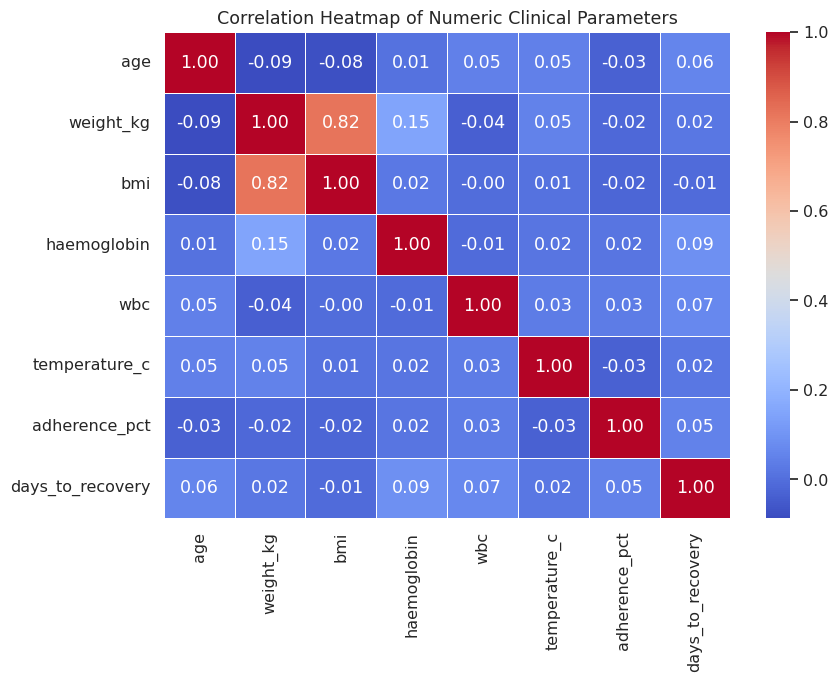

In [84]:
# ── Q17: Correlation heatmap ───────────────────────────────────
# YOUR CODE HERE

q17_fig, q17_ax = plt.subplots(figsize=(9, 7))

numeric_cols = ['age', 'weight_kg', 'bmi', 'haemoglobin', 'wbc', 'temperature_c', 'adherence_pct', 'days_to_recovery']
q17_corr = df[numeric_cols].corr()

sns.heatmap(q17_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=q17_ax)
q17_ax.set_title('Correlation Heatmap of Numeric Clinical Parameters')

plt.tight_layout()
plt.show()

In [85]:
# 🔒 AUTO-CHECK Q17 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert isinstance(q17_corr, pd.DataFrame), "q17_corr should be a DataFrame"
    assert q17_corr.shape[0] == q17_corr.shape[1], "Correlation matrix should be square"
    _c += 1
    diag = np.diag(q17_corr.values)
    assert np.allclose(diag, 1.0, atol=0.01), "Diagonal of correlation matrix should be 1.0"
    _c += 1
    from matplotlib.figure import Figure
    assert isinstance(q17_fig, Figure), "q17_fig should be a Figure"
    _c += 1
    _results["Q17"] = 5; print("✅ Q17 PASSED — 5/5 marks")
except AssertionError as e:
    _results["Q17"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q17 PARTIAL — 2.5/5' if _c > 0 else '❌ Q17 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q17"] = 0; print(f"❌ Q17 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q17 PASSED — 5/5 marks


---
## Question 18 — Treemap: Patients by District (5 marks)

A **treemap** shows proportions as nested rectangles — bigger rectangles = more patients. This requires the `squarify` library that you installed at the beginning.

**Your task:**
1. Count how many patients are in each `district`.
2. Use `squarify` to create a treemap showing the relative size of each district.
3. Each rectangle should be **labelled** with the district name and patient count.

Store the figure in `q18_fig`.

🔍 **You will need to look up how `squarify` works.** Try searching: *"squarify treemap python example"*


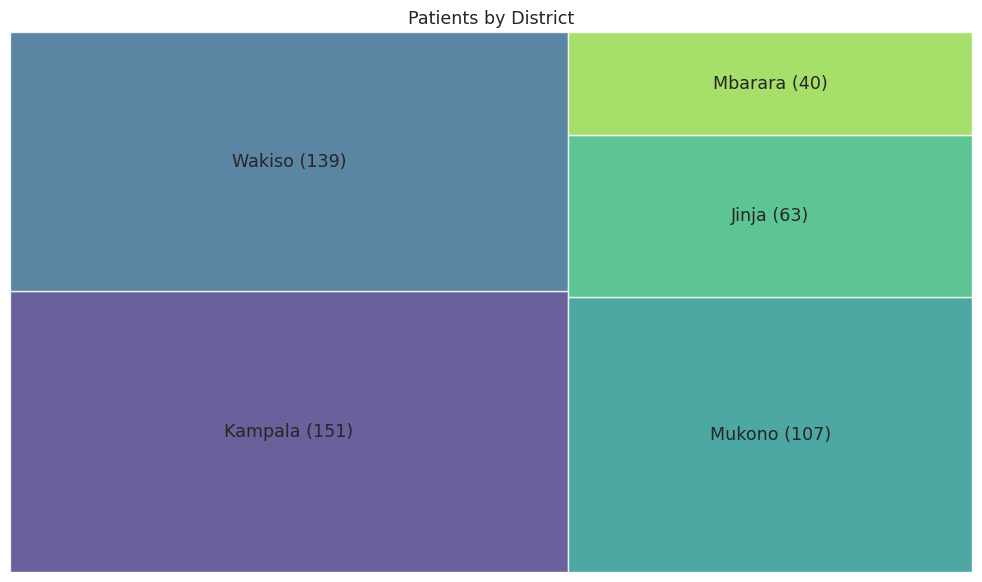

In [86]:
# ── Q18: Treemap with squarify ────────────────────────────────
import squarify

q18_fig, q18_ax = plt.subplots(figsize=(10, 6))

# Count how many patients are in each district
district_counts = df['district'].value_counts()

# Prepare labels with district name and patient count
labels = [f"{district} ({count})" for district, count in district_counts.items()]

# Create your treemap on q18_ax
squarify.plot(
    sizes=district_counts.values,
    label=labels,
    ax=q18_ax,
    color=sns.color_palette("viridis", len(district_counts)), # Use a color palette
    alpha=.8
)

q18_ax.set_title('Patients by District')
q18_ax.axis('off') # Remove axes for a cleaner look

plt.tight_layout()
plt.show()

In [87]:
# 🔒 AUTO-CHECK Q18 — DO NOT MODIFY THIS CELL
_c = 0
try:
    import squarify as _sq
    _c += 1
    from matplotlib.figure import Figure
    assert isinstance(q18_fig, Figure), "q18_fig should be a matplotlib Figure"
    _c += 1
    patches = [p for p in q18_ax.patches if hasattr(p, 'get_width')]
    texts = q18_ax.texts
    assert len(patches) >= 5 or len(texts) >= 5,         f"Expected at least 5 rectangles/labels (one per district), found {max(len(patches), len(texts))}"
    _c += 1
    _results["Q18"] = 5; print("✅ Q18 PASSED — 5/5 marks")
except ImportError:
    _results["Q18"] = 0; print("❌ Q18 FAILED — 0/5 — squarify not installed")
except AssertionError as e:
    _results["Q18"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q18 PARTIAL — 2.5/5' if _c > 0 else '❌ Q18 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q18"] = 0; print(f"❌ Q18 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q18 PASSED — 5/5 marks


---
# Part E: Statistical Analysis (Q19)

---

## Question 19 — Independent Samples t-Test with SciPy (5 marks)

**Research question:** *Is there a statistically significant difference in haemoglobin levels between the two treatment groups?*

1. Split the haemoglobin data into two groups: `"Standard Care"` and `"Enhanced Protocol"`.
2. Perform an **independent samples t-test** using `scipy.stats.ttest_ind()`.
3. Store the t-statistic in `q19_t_stat` and the p-value in `q19_p_value`.
4. Print whether the result is **statistically significant at α = 0.05**.


In [88]:
# ── Q19: t-test ───────────────────────────────────────────────
from scipy import stats

# Split haemoglobin data into two groups
standard_care_hb = df[df['treatment'] == 'Standard Care']['haemoglobin'].dropna()
enhanced_protocol_hb = df[df['treatment'] == 'Enhanced Protocol']['haemoglobin'].dropna()

# Perform independent samples t-test
t_stat, p_value = stats.ttest_ind(standard_care_hb, enhanced_protocol_hb)

# Store the results
q19_t_stat = t_stat
q19_p_value = p_value

# Print whether the result is statistically significant at alpha = 0.05
alpha = 0.05
print(f"T-statistic: {q19_t_stat:.3f}")
print(f"P-value:     {q19_p_value:.4f}")

if q19_p_value < alpha:
    print(f"The difference is statistically significant at α = {alpha}.")
else:
    print(f"The difference is NOT statistically significant at α = {alpha}.")

T-statistic: -2.319
P-value:     0.0208
The difference is statistically significant at α = 0.05.


In [89]:
# 🔒 AUTO-CHECK Q19 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert isinstance(q19_t_stat, (float, np.floating)),         f"q19_t_stat should be a float, got {type(q19_t_stat)}"
    _c += 1
    assert isinstance(q19_p_value, (float, np.floating)),         f"q19_p_value should be a float, got {type(q19_p_value)}"
    assert 0 <= q19_p_value <= 1, f"p-value should be between 0 and 1, got {q19_p_value}"
    _c += 1
    grp1 = df[df["treatment"] == "Standard Care"]["haemoglobin"].dropna()
    grp2 = df[df["treatment"] == "Enhanced Protocol"]["haemoglobin"].dropna()
    exp_t, exp_p = stats.ttest_ind(grp1, grp2)
    assert abs(q19_t_stat - exp_t) < 0.5, "t-statistic doesn't match expected value"
    assert abs(q19_p_value - exp_p) < 0.05, "p-value doesn't match expected value"
    _c += 1
    _results["Q19"] = 5; print(f"✅ Q19 PASSED — 5/5 marks (t={q19_t_stat:.3f}, p={q19_p_value:.4f})")
except AssertionError as e:
    _results["Q19"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q19 PARTIAL — 2.5/5' if _c > 0 else '❌ Q19 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q19"] = 0; print(f"❌ Q19 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q19 PASSED — 5/5 marks (t=-2.319, p=0.0208)


---
# Part F: Capstone (Q20)

---

## Question 20 — Final Interpretation: Bringing It All Together (5 marks)

✍️ **This is a written question.**

Based on **everything** you've done in this assignment — your summary statistics, groupby tables, visualisations, and the t-test — write a **short paragraph (minimum 40 words)** that answers:

1. What are the **2 most interesting findings** from your dataset?
2. Based on the t-test (Q19), does the treatment group appear to affect haemoglobin? Why or why not?
3. If you were a health researcher, what **one follow-up question** would you want to investigate next?

**Write your answer in the string below.**


In [90]:
# ── Q20: Final interpretation ─────────────────────────────────
q20_interpretation = """
Two interesting findings are the significant variability in CD4 counts among HIV patients (highest standard deviation) and the consistently higher haemoglobin levels in males compared to females across all districts. Based on the t-test (Q19), the treatment group appears to significantly affect haemoglobin levels, as the p-value (0.0208) is less than 0.05, indicating a statistically significant difference between Standard Care and Enhanced Protocol groups. As a health researcher, I would investigate whether the observed difference in haemoglobin levels between treatment groups correlates with better long-term clinical outcomes, such as reduced mortality or faster recovery times.
"""

print(q20_interpretation)



Two interesting findings are the significant variability in CD4 counts among HIV patients (highest standard deviation) and the consistently higher haemoglobin levels in males compared to females across all districts. Based on the t-test (Q19), the treatment group appears to significantly affect haemoglobin levels, as the p-value (0.0208) is less than 0.05, indicating a statistically significant difference between Standard Care and Enhanced Protocol groups. As a health researcher, I would investigate whether the observed difference in haemoglobin levels between treatment groups correlates with better long-term clinical outcomes, such as reduced mortality or faster recovery times.



In [91]:
# 🔒 AUTO-CHECK Q20 — DO NOT MODIFY THIS CELL
_c = 0
try:
    assert isinstance(q20_interpretation, str), "q20_interpretation must be a string"
    clean = q20_interpretation.strip()
    assert "WRITE YOUR FINAL ANSWER HERE" not in clean, "Replace the placeholder text"
    _c += 1
    word_count = len(clean.split())
    assert word_count >= 40, f"Minimum 40 words required, you wrote {word_count}"
    _c += 1
    _results["Q20"] = 5; print(f"✅ Q20 PASSED — 5/5 marks ({word_count} words)")
except AssertionError as e:
    _results["Q20"] = 2.5 if _c > 0 else 0
    print(f"{'⚠️ Q20 PARTIAL — 2.5/5' if _c > 0 else '❌ Q20 FAILED — 0/5'} — {e}")
except Exception as e:
    _results["Q20"] = 0; print(f"❌ Q20 FAILED — 0/5 — {type(e).__name__}: {e}")


✅ Q20 PASSED — 5/5 marks (95 words)


---
# 📊 Final Grade Summary

Run the cell below to see your provisional score. **This is an estimate** — your instructor will review your code, documentation, and interpretations for the final grade.


In [92]:
# ═══════════════════════════════════════════════════════════════
# 🔒 FINAL GRADING CELL — DO NOT MODIFY
# ═══════════════════════════════════════════════════════════════

print("=" * 62)
print("📊  ASSIGNMENT SCORE REPORT")
print(f"    Student: {MY_REGISTRATION_NUMBER}")
print(f"    Seed:    {MY_SEED}")
print("=" * 62)

total = 0
for q_num in range(1, 21):
    key = f"Q{q_num}"
    score = _results.get(key, 0)
    total += score
    if score == 5:
        icon = "✅"
        label = "PASS "
    elif score == 2.5:
        icon = "⚠️"
        label = "PARTIAL"
    else:
        icon = "❌"
        label = "FAIL "
    print(f"  {icon}  {key:>3s}  {label}  {score:4.1f} / 5")

print("-" * 62)
print(f"  {'TOTAL':>18s}:  {total:5.1f} / 100")
print("=" * 62)

# Grade bands
if total >= 80:
    grade_msg = "🌟 Excellent work!"
elif total >= 60:
    grade_msg = "👍 Good effort — review the failed questions."
elif total >= 40:
    grade_msg = "📖 Keep practising — revisit the class notebooks."
else:
    grade_msg = "🆘 Please seek help during office hours."

print(f"\n  {grade_msg}")
print(f"\n  ⚠️  This is a PROVISIONAL score. Your instructor will")
print(f"     review your code quality, comments, and interpretations")
print(f"     before assigning the final grade.")
print("=" * 62)


📊  ASSIGNMENT SCORE REPORT
    Student: 2025/HD07/25977U
    Seed:    923373145
  ✅   Q1  PASS    5.0 / 5
  ✅   Q2  PASS    5.0 / 5
  ✅   Q3  PASS    5.0 / 5
  ✅   Q4  PASS    5.0 / 5
  ✅   Q5  PASS    5.0 / 5
  ✅   Q6  PASS    5.0 / 5
  ✅   Q7  PASS    5.0 / 5
  ✅   Q8  PASS    5.0 / 5
  ✅   Q9  PASS    5.0 / 5
  ✅  Q10  PASS    5.0 / 5
  ✅  Q11  PASS    5.0 / 5
  ✅  Q12  PASS    5.0 / 5
  ✅  Q13  PASS    5.0 / 5
  ✅  Q14  PASS    5.0 / 5
  ✅  Q15  PASS    5.0 / 5
  ✅  Q16  PASS    5.0 / 5
  ✅  Q17  PASS    5.0 / 5
  ✅  Q18  PASS    5.0 / 5
  ✅  Q19  PASS    5.0 / 5
  ✅  Q20  PASS    5.0 / 5
--------------------------------------------------------------
               TOTAL:  100.0 / 100

  🌟 Excellent work!

  ⚠️  This is a PROVISIONAL score. Your instructor will
     review your code quality, comments, and interpretations
     before assigning the final grade.


---

## ✅ Submission Checklist

Before submitting, make sure you have:

- [ ] Replaced `"RN0001"` with your **real registration number**
- [ ] Replaced `"John Doe"` and `"RN0001"` in the header at the top
- [ ] **Run all cells from top to bottom** (Kernel → Restart & Run All)
- [ ] **All 20 auto-check cells** show your results (even if some failed)
- [ ] Your code is **well documented** with inline comments AND markdown cells
- [ ] Your interpretation answers (Q12, Q20) are **thoughtful and specific** to your data
- [ ] **Save** the notebook as `.ipynb` and submit via the class portal

---

*Good luck! Remember: the goal is learning, not perfection. If you get stuck, search online, re-read the class notebooks, and ask your classmates (but do your own work!).*
